In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
data = pd.read_csv('student_data.csv')
data.head()

,name,attendance,internal,assignment,practical,quiz,previous_cgpa,risk_factor
0,Diya Prajapati,91.9,94.5,93.2,80.1,77.6,8.16,low
1,Meera Purohit,82.9,69.6,69.6,85.4,65.3,7.12,low
2,Akansha Saini,72.4,62.4,63.3,80.8,54.8,6.84,low
3,Anjali Purohit,72.8,70.9,79.0,72.6,75.2,6.64,low
4,Khushi Jain,80.4,78.0,79.8,77.4,71.5,6.99,low


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           750 non-null    str    
 1   attendance     750 non-null    float64
 2   internal       750 non-null    float64
 3   assignment     750 non-null    float64
 4   practical      750 non-null    float64
 5   quiz           750 non-null    float64
 6   previous_cgpa  750 non-null    float64
 7   risk_factor    750 non-null    str    
dtypes: float64(6), str(2)
memory usage: 47.0 KB


In [ ]:
X = data.drop(columns=["name", "risk_factor"])
y = data["risk_factor"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model initialization:
- Random Forest
- Gradient Boosting
- Logistic Regression
- Support Vector Machine

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        random_state=42
    ),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            probability=True,
            random_state=42
        ))
    ])
}


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

In [ ]:
results = []

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    })

results_df = pd.DataFrame(results)

c:\Users\Hp\OneDrive\Desktop\my repos\eduagent\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Hp\OneDrive\Desktop\my repos\eduagent\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Hp\OneDrive\Desktop\my repos\eduagent\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Hp\OneDrive\Desktop\my repos\eduagent\venv\Lib\site-packages\sklearn\svm\_base.py:236

## Cross-validation scores

In [ ]:
print("\nCross Validation Results:")
print(results_df.round(4))


Cross Validation Results:
                 Model  Accuracy  Precision  Recall      F1
0        Random Forest    0.8987     0.8857  0.8858  0.8843
1    Gradient Boosting    0.8893     0.8799  0.8690  0.8717
2  Logistic Regression    0.9000     0.8907  0.8824  0.8840
3                  SVM    0.9080     0.9011  0.8871  0.8924


## Feature Importance for RandomForestClassifier

In [ ]:
rf_model = models['Random Forest']
rf_model.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})
rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importance:")
print(rf_importance)


Random Forest Feature Importance:
         Feature  Importance
1       internal    0.289682
5  previous_cgpa    0.205455
4           quiz    0.161458
3      practical    0.120052
0     attendance    0.111846
2     assignment    0.111507


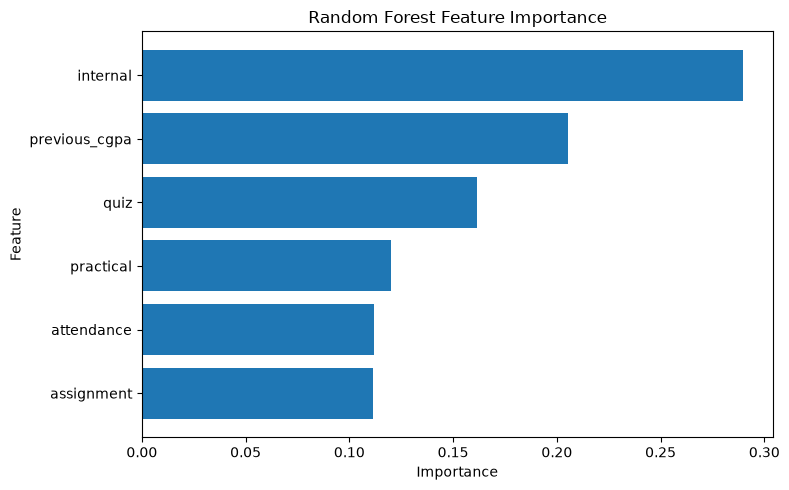

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Feature Importance for LogisticRegression

In [ ]:
lr = models["Logistic Regression"]
lr.fit(X_train, y_train)
coefficients = lr.named_steps["model"].coef_[0]

lr_importance = pd.DataFrame({
    "Feature": X.columns,
    "Absolute_Importance": np.abs(coefficients)
}).sort_values(by="Absolute_Importance", ascending=False)

print(lr_importance)

         Feature  Absolute_Importance
0     attendance             1.384720
1       internal             1.340434
3      practical             1.295058
4           quiz             0.966776
2     assignment             0.739293
5  previous_cgpa             0.429650


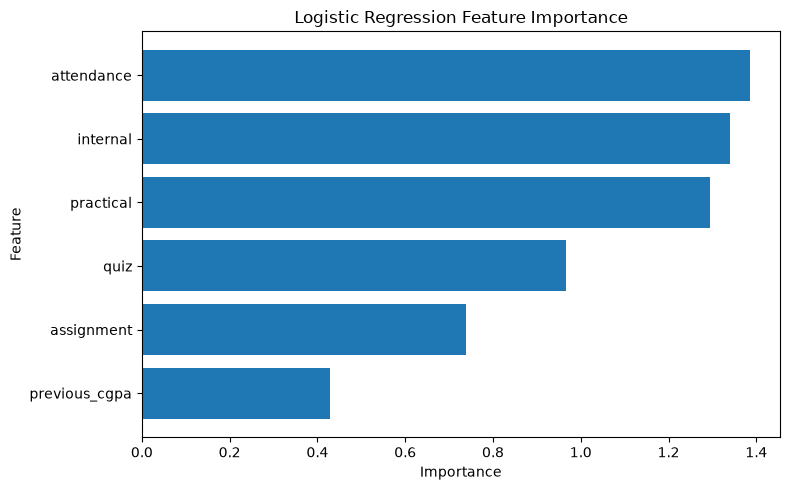

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    lr_importance["Feature"],
    lr_importance["Absolute_Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Feature Importance for GradientBoosting

In [ ]:
gb = models["Gradient Boosting"]

gb.fit(X_train, y_train)

gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(gb_importance)

         Feature  Importance
1       internal    0.493081
0     attendance    0.116814
4           quiz    0.116033
3      practical    0.107504
5  previous_cgpa    0.083324
2     assignment    0.083243


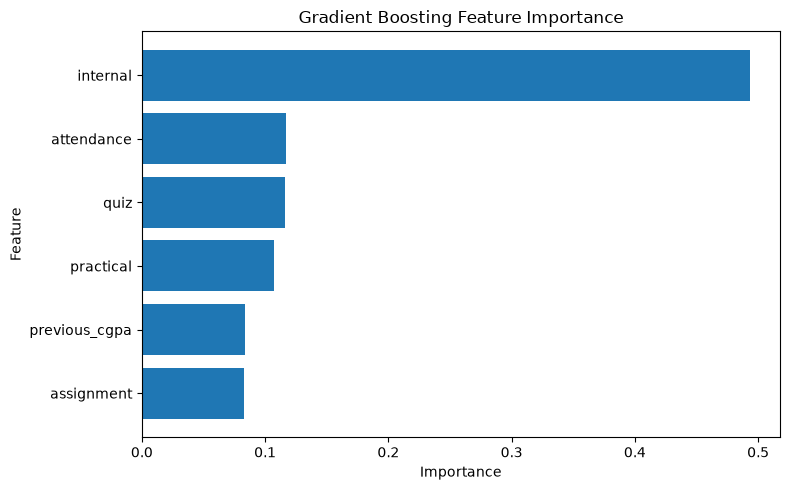

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    gb_importance["Feature"],
    gb_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Feature Importance for Support Vector Machine

In [ ]:
from sklearn.inspection import permutation_importance

svm = models["SVM"]
svm.fit(X_train, y_train)

result = permutation_importance(
    svm,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro"
)

svm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean * 10,
    "Std": result.importances_std * 10
}).sort_values(by="Importance", ascending=False)

print(svm_importance)

c:\Users\Hp\OneDrive\Desktop\my repos\eduagent\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


         Feature  Importance       Std
1       internal    0.988385  0.355980
0     attendance    0.560799  0.154893
4           quiz    0.453401  0.137337
3      practical    0.287482  0.139834
2     assignment    0.160716  0.100392
5  previous_cgpa    0.033538  0.196715


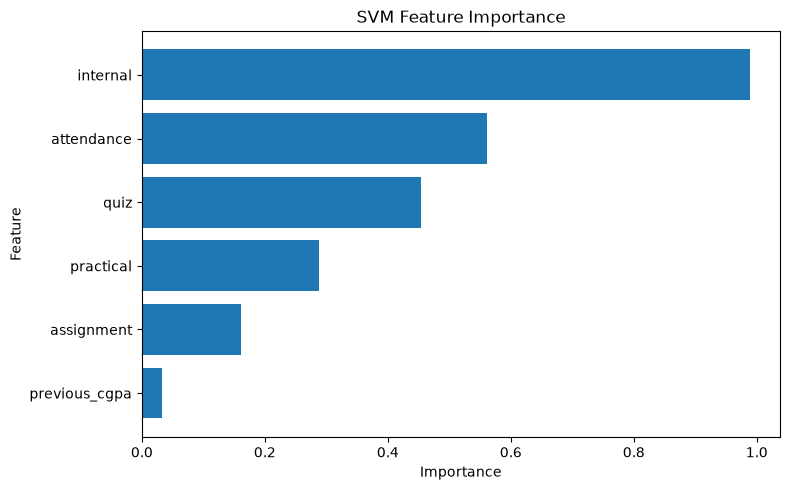

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    svm_importance["Feature"],
    svm_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("SVM Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Every models importance comparision

In [ ]:
importance_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        scoring="f1_macro"
    )

    importance_results[name] = pd.DataFrame({
        "Feature": X.columns,
        "Importance": result.importances_mean * 10,
        "Std": result.importances_std * 10
    }).sort_values("Importance", ascending=False)

    print(f"\n{name}")
    print(importance_results[name])


Random Forest
         Feature  Importance       Std
1       internal    0.962367  0.197665
0     attendance    0.408579  0.141669
3      practical    0.345795  0.246004
4           quiz    0.268932  0.100829
2     assignment    0.034801  0.120549
5  previous_cgpa    0.009390  0.096193

Gradient Boosting
         Feature  Importance       Std
1       internal    1.009774  0.263391
4           quiz    0.694259  0.088493
0     attendance    0.674820  0.102755
3      practical    0.646852  0.310020
2     assignment    0.232207  0.056649
5  previous_cgpa    0.223054  0.143113

Logistic Regression
         Feature  Importance       Std
0     attendance    0.795139  0.121512
1       internal    0.762067  0.227077
3      practical    0.576050  0.178138
4           quiz    0.307787  0.139630
2     assignment    0.254901  0.109384
5  previous_cgpa    0.006173  0.104714


c:\Users\Hp\OneDrive\Desktop\my repos\eduagent\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



SVM
         Feature  Importance       Std
1       internal    0.988385  0.355980
0     attendance    0.560799  0.154893
4           quiz    0.453401  0.137337
3      practical    0.287482  0.139834
2     assignment    0.160716  0.100392
5  previous_cgpa    0.033538  0.196715


In [ ]:
import pickle

with open('saved_models/model.pkl', 'wb') as f:
    pickle.dump(models['Logistic Regression'], f)
    print("Logistic Regression model saved to model.pkl")

Logistic Regression model saved to model.pkl
